In [2]:
import pandas as pd
from datetime import datetime
import time

import seaborn as sns
from matplotlib import pyplot as plt
from scipy import stats
import numpy as np
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler, RobustScaler, QuantileTransformer, PowerTransformer
from scipy.stats import skew
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.inspection import permutation_importance
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
import numpy as np
import pandas as pd
from xgboost import XGBClassifier
from catboost import CatBoostClassifier, Pool
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.feature_selection import RFE, SelectKBest, f_classif
from sklearn.pipeline import Pipeline
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from catboost import CatBoostClassifier
from sklearn.preprocessing import MinMaxScaler
from lightgbm import LGBMClassifier
import shap
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import (
    train_test_split, cross_val_score, GridSearchCV, KFold
)


from sklearn.metrics import accuracy_score, f1_score
from sklearn.inspection import permutation_importance
from sklearn.feature_selection import RFE

from xgboost import XGBClassifier
from catboost import CatBoostClassifier
import shap

from sklearn.model_selection import TimeSeriesSplit
from catboost import CatBoostClassifier
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import talib
import warnings
from vmdpy import VMD
from pandas_datareader import data as pdr
from datetime import datetime, timedelta

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)
import copy
import random
from torch.utils.data import Dataset, DataLoader
warnings.filterwarnings('ignore')
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import squareform

Загрузка сформированных фичей

In [3]:
df_base = pd.read_csv(r'C:\Users\User\my\py\practise\solana\data\sol_price_from_2020.csv')
df_base=df_base[df_base['time']>'2021-01-01']
df_base['time'] = pd.to_datetime(df_base['time'])
df_base.rename(columns={"time": "date"}, inplace=True)
df_base.rename(columns={"volumeto": "trading_volume_usd"}, inplace=True)
price = df_base['close'].values


In [4]:
df_vmd_roll = pd.read_csv(r'C:\Users\User\my\py\practise\solana\data\SOL_VMD.csv')

In [5]:
df_trends=pd.read_csv(r"C:\Users\User\my\py\practise\solana\data\solana_search_trends_mounthly_from2020.csv")
df_trends.rename(columns={"Solana": "Solana_trends"}, inplace=True)
df_trends.rename(columns={"Time": "date"}, inplace=True)
df_trends['date'] = pd.to_datetime(df_trends['date'])
df_trends = df_trends.set_index('date')
df_trends = df_trends.resample('D').ffill()

df_trends = df_trends.reset_index()
df_trends = df_trends.rename(columns={"solana": "search_trends"})
df_trends

,date,search_trends
0,2019-12-01,4
1,2019-12-02,4
2,2019-12-03,4
3,2019-12-04,4
4,2019-12-05,4
...,...,...
2250,2026-01-28,37
2251,2026-01-29,37
2252,2026-01-30,37
2253,2026-01-31,37


In [6]:
df_flows=pd.read_csv(r'C:\Users\User\my\py\practise\solana\data\flows_from2020.csv')

In [7]:
df_flows.rename(columns={"total_amount": "total_flow"}, inplace=True)

In [8]:
btc_price=pd.read_csv(r"C:\Users\User\my\py\practise\solana\data\btc_price_from_2020.csv")
btc_price.rename(columns={"close": "btc_close"}, inplace=True)
btc_price.rename(columns={"time": "date"}, inplace=True)
btc_price=btc_price[['date','btc_close']]

Ставка ФРС

In [9]:
fed_rate=pd.read_csv(r"C:\Users\User\my\py\practise\solana\data\fed_rate_daily_2020.csv")
fed_rate

,date,fed_rate
0,2019-02-19,2.40
1,2019-02-20,2.40
2,2019-02-21,2.40
3,2019-02-22,2.40
4,2019-02-23,2.40
...,...,...
2546,2026-02-08,3.64
2547,2026-02-09,3.64
2548,2026-02-10,3.64
2549,2026-02-11,3.64


dollar index

In [10]:
dollar_index=pd.read_csv(r'C:\Users\User\my\py\practise\solana\data\dollar_index_2020.csv')
dollar_index = dollar_index.sort_values('date')

dollar_index

,date,dxy
0,2019-04-15,114.4950
1,2019-04-16,114.6756
2,2019-04-17,114.5141
3,2019-04-18,114.7073
4,2019-04-19,114.6977
...,...,...
2541,2026-03-30,121.2851
2542,2026-03-31,121.0350
2543,2026-04-01,120.1198
2544,2026-04-02,120.5030


SP500

In [11]:
df_sp500=pd.read_csv(r"C:\Users\User\my\py\practise\solana\data\sp500_2020_preprocessed.csv")

df_sp500.dtypes

date            object
sp500_close    float64
dtype: object

In [12]:

# даты халвингов
halvings = pd.to_datetime([
    "2012-11-28",
    "2016-07-09",
    "2020-05-11",
    "2024-04-20",
    '2028-04-09'
])

# временной диапазон
dates = pd.date_range("2019-01-01", "2026-01-01", freq="D")

window = 365*4  # дней влияния

index_values = []

for date in dates:

    distances = [(window - abs((date - h).days)) / window for h in halvings]

    # берем максимальное влияние
    value = max(0, max(distances))

    index_values.append(value)

halving_index = pd.DataFrame({
    "date": dates,
    "halving_index": index_values
}).set_index("date")
halving_index = halving_index.reset_index()
halving_index

,date,halving_index
0,2019-01-01,0.660274
1,2019-01-02,0.660959
2,2019-01-03,0.661644
3,2019-01-04,0.662329
4,2019-01-05,0.663014
...,...,...
2553,2025-12-28,0.577397
2554,2025-12-29,0.576712
2555,2025-12-30,0.576027
2556,2025-12-31,0.575342


In [13]:
df_oca=pd.read_csv(r'C:\Users\User\my\py\practise\solana\features\features_daily_2020.csv')
df_oca=df_oca.drop(columns=['Unnamed: 0','time','timestamp'])

In [14]:
df_technical=pd.read_csv(r'C:\Users\User\my\py\practise\solana\data\technical_2020.csv')
df_technical.rename(columns={"time": "date"}, inplace=True)


In [15]:
df_price = pd.read_csv(r'C:\Users\User\my\py\practise\solana\data\sol_price_from_2020.csv')
df_price=df_price[df_price['time']>'2021-01-01']
df_price['time'] = pd.to_datetime(df_price['time'])
df_price=df_price.drop(columns=['conversionType','conversionSymbol'])
df_price.rename(columns={"time": "date"}, inplace=True)
df_price=df_price[['date','close']]


base

In [16]:
dfs = [df_vmd_roll, df_trends, df_flows, btc_price, halving_index,dollar_index,df_sp500,fed_rate]

for df in dfs:
    df['date'] = pd.to_datetime(df['date'])
df_merged_base = df_base \
    .merge(df_trends, on='date', how='inner') \
    .merge(btc_price, on='date', how='inner') \
    .merge(halving_index, on='date', how='inner')\
    .merge(dollar_index, on='date', how='inner')\
    .merge(df_sp500, on='date', how='inner')\
    .merge(fed_rate, on='date', how='inner')\
    .merge(df_vmd_roll, on='date', how='inner')

df_merged_base=df_merged_base.drop(columns=['high','low','open','volumefrom','conversionType','conversionSymbol'])
df_merged_base=df_merged_base[df_merged_base['date']>'2021-01-01']
df_merged_base=df_merged_base[df_merged_base['date']<'2025-11-01']

TA

In [17]:
dfs = [df_base, df_technical]

for df in dfs:
    df['date'] = pd.to_datetime(df['date'])
df_merged_ta = df_price \
    .merge(df_technical, on='date', how='inner')\
    .merge(df_base, on="date", how='inner')

df_merged_ta=df_merged_ta[df_merged_ta['date']>'2021-01-01']
df_merged_ta=df_merged_ta[df_merged_ta['date']<'2025-11-01']
try:
    df_merged_ta.rename(columns={"close_x": "close"}, inplace=True)
    df_merged_ta=df_merged_ta.drop(columns=['high','low','open','volumefrom','conversionType','conversionSymbol','close_y'])
except:
    print(3)

In [17]:
df_merged_ta.columns

Index(['date', 'close', 'CDL_ENGULFING', 'CDL_HAMMER', 'CDL_HANGINGMAN',
       'CDL_DOJI', 'CDL_MORNINGSTAR', 'CDL_EVENINGSTAR', 'CDL_3WHITESOLDIERS',
       'CDL_3BLACKCROWS', 'CDL_PIERCING', 'CDL_DARKCLOUD', 'EMA_5', 'EMA_30',
       'EMA_100', 'macd', 'macd_signal', 'macd_diff', 'macd_z',
       'macd_price_slope_diff', 'divergence_strength', 'rsi', 'bb_ma',
       'bb_std', 'bb_upper', 'bb_lower', 'bb_dist_upper', 'bb_dist_lower',
       'bb_pos', 'bb_break_upper', 'bb_break_lower',
       'bb_break_lower_cumulative', 'bb_break_upper_cumulative', 'OBV', 'AD',
       'CMF', 'MFI', 'volume_avg', 'ForceIndex', 'hammer_rsi_low',
       'engulfing_near_bb_lower', 'mfi_oversold_breakout', 'macd_bull_cross',
       'bb_rsi_overbought', 'force_volume_spike', '3crows_rsi_high',
       'bullish_signals', 'bearish_signals', 'doji_rsi_extreme',
       'hammer_bb_low', 'hangingman_bearish', 'engulfing_with_divergence',
       'morningstar_reversal', 'eveningstar_reversal', 'soldiers_after_acc'

OCA

In [18]:
dfs = [df_base, df_oca]

for df in dfs:
    df['date'] = pd.to_datetime(df['date'])
df_merged_oca = df_price \
    .merge(df_oca, on='date', how='inner')\
    .merge(df_base, on="date", how='inner')

df_merged_oca=df_merged_oca[df_merged_oca['date']>'2021-01-01']
df_merged_oca=df_merged_oca[df_merged_oca['date']<'2025-11-01']
try:
    df_merged_oca.rename(columns={"close_x": "close"}, inplace=True)
    df_merged_oca=df_merged_oca.drop(columns=['high','low','open','volumefrom','trading_volume_usd','conversionType','conversionSymbol','close_y'])
except:
    print(3)


Объединение датасетов код

In [19]:
def merge_feature_blocks(left, right, on="date", keep_close=True):
    left = left.copy()
    right = right.copy()

    left[on] = pd.to_datetime(left[on])
    right[on] = pd.to_datetime(right[on])

    protected = {on}

    if keep_close:
        protected.add("close")

    drop_from_right = []

    for col in right.columns:
        if col == on:
            continue

        if col in left.columns:
            drop_from_right.append(col)

    right = right.drop(columns=drop_from_right, errors="ignore")

    out = left.merge(right, on=on, how="inner")
    out = out.sort_values(on).reset_index(drop=True)

    return out


In [20]:
df_baseline_oca = merge_feature_blocks(df_merged_base, df_merged_oca)
df_baseline_ta = merge_feature_blocks(df_merged_base, df_merged_ta)
df_oca_ta = merge_feature_blocks(df_merged_oca, df_merged_ta)
df_full = merge_feature_blocks(df_baseline_ta, df_oca_ta)

oca+ta+base

In [21]:
dfs = [df_base, df_trends, btc_price, halving_index,dollar_index,df_sp500,fed_rate,df_technical,df_oca]

for df in dfs:
    df['date'] = pd.to_datetime(df['date'])
df_merged_oca_ta = df_price \
    .merge(df_trends, on='date', how='inner') \
    .merge(btc_price, on='date', how='inner') \
    .merge(halving_index, on='date', how='inner')\
    .merge(dollar_index, on='date', how='inner')\
    .merge(df_sp500, on='date', how='inner')\
    .merge(fed_rate, on='date', how='inner')\
    .merge(df_technical, on='date', how='inner')\
    .merge(df_oca, on='date', how='inner')\
    .merge(df_base, on="date", how='inner')

df_merged_oca_ta=df_merged_oca_ta[df_merged_oca_ta['date']>'2021-01-01']
df_merged_oca_ta=df_merged_oca_ta[df_merged_oca_ta['date']<'2025-11-01']
try:
    df_merged_oca_ta.rename(columns={"close_x": "close"}, inplace=True)
    df_merged_oca_ta=df_merged_oca_ta.drop(columns=['high','low','open','volumefrom','conversionType','conversionSymbol','close_y'])
except:
    print(3)

In [22]:
df_baseline_oca.to_csv(r'C:\Users\User\my\py\practise\solana\datasets\baseline_oca.csv', index=False)
df_baseline_ta.to_csv(r'C:\Users\User\my\py\practise\solana\datasets\baseline_ta.csv', index=False)
df_oca_ta.to_csv(r'C:\Users\User\my\py\practise\solana\datasets\oca_ta.csv', index=False)
df_full.to_csv(r'C:\Users\User\my\py\practise\solana\datasets\full.csv', index=False)
df_merged_oca.to_csv(r'C:\Users\User\my\py\practise\solana\datasets\merged_oca.csv', index=False)
df_merged_ta.to_csv(r'C:\Users\User\my\py\practise\solana\datasets\merged_ta.csv', index=False)
df_merged_base.to_csv(r'C:\Users\User\my\py\practise\solana\datasets\merged_base.csv', index=False)

Полный пайплайн

In [ ]:
import importlib
import pandas as pd
import scripts.run_article_ready_hypothesis_pipeline as pipe

importlib.reload(pipe)


cfg = pipe.Config(
    feature_selection_mode="fixed_train",
    fee=0.001,

    # Full model set
    run_sequence_models=True,
    tune_sequence_models=True,

    # LSTM / BiLSTM settings
    sequence_epochs=30,
    sequence_patience=5,
    sequence_batch_size=64,
    sequence_hidden_grid=(32, 64, 96),
    sequence_dropout_grid=(0.0, 0.2),
    sequence_lr_grid=(0.001, 0.0005),
    sequence_tune_max_combinations=12,

    # Statistical robustness
    bootstrap_iters=1000,
    block_bootstrap_iters=1000,
    block_size=10,

    # Feature selection diagnostics
    permutation_repeats=5,
    shap_eval_size=350,
)

holdout_periods = [
    ("2023-11-01", "2024-05-01"),
    ("2024-05-01", "2024-11-01"),
    ("2024-11-01", "2025-05-01"),
    ("2025-05-01", "2025-11-01"),
]


block_ablation_full = pipe.run_block_ablation_from_csvs(
    cfg=cfg,
    holdout_periods=holdout_periods,
    out_dir="results/block_ablation_pipeline_full",
)


df_oca = pd.read_csv("datasets/merged_oca.csv")

oca_internal_full = pipe.run_oca_internal_ablation(
    df_oca,
    cfg=cfg,
    holdout_periods=holdout_periods,
    out_dir="results/oca_internal_ablation_pipeline_full",
)


print("BLOCK ABLATION FULL SAVED TO:")
print(block_ablation_full["out_dir"])

print("\nOCA INTERNAL ABLATION FULL SAVED TO:")
print(oca_internal_full["out_dir"])

print("\nBlock-level classification deltas:")
display(block_ablation_full["ablation"]["classification_delta_summary"])

print("\nBlock-level equity deltas:")
display(block_ablation_full["ablation"]["equity_delta_summary"])

print("\nOCA internal classification deltas:")
display(oca_internal_full["ablation"]["classification_delta_summary"])

print("\nOCA internal equity deltas:")
display(oca_internal_full["ablation"]["equity_delta_summary"])



=== Ablation holdout: 2023-11-01 to 2024-05-01 ===
Running fixed_train pipeline for baseline...
Running fixed_train pipeline for oca...
Running fixed_train pipeline for ta...
Running fixed_train pipeline for baseline_oca...
Running fixed_train pipeline for baseline_ta...
Running fixed_train pipeline for oca_ta...
Running fixed_train pipeline for full...

Model metrics (fixed_train):
     dataset         model   n  accuracy  balanced_accuracy  precision   recall       f1       mcc  positive_rate  class_1_share  roc_auc    brier  logloss
    baseline     always_up 182  0.532967           0.500000   0.532967 1.000000 0.695341  0.000000       1.000000       0.532967 0.500000 0.249203 0.691557
    baseline          lstm 182  0.538462           0.521164   0.546763 0.783505 0.644068  0.049715       0.763736       0.532967 0.506367 0.249596 0.692340
    baseline      momentum 182  0.527473           0.525409   0.556701 0.556701 0.556701  0.050819       0.532967       0.532967 0.525409 0.24975

,comparison,with_block,reference,model,mean_delta_f1,std_delta_f1,positive_delta_f1_count,n_delta_f1,mean_delta_balanced_accuracy,std_delta_balanced_accuracy,...,positive_delta_roc_auc_count,n_delta_roc_auc,mean_delta_brier_improvement,std_delta_brier_improvement,positive_delta_brier_improvement_count,n_delta_brier_improvement,mean_delta_logloss_improvement,std_delta_logloss_improvement,positive_delta_logloss_improvement_count,n_delta_logloss_improvement
0,baseline_added_to_oca_ta,full,oca_ta,always_up,0.000000,0.000000,0,4,0.000000,0.000000,...,0,4,0.000000,0.000000,0,4,0.000000,0.000000,0,4
1,baseline_added_to_oca_ta,full,oca_ta,bilstm,-0.126505,0.244534,2,4,0.043651,0.010903,...,4,4,-0.001539,0.005124,3,4,-0.004988,0.013350,3,4
2,baseline_added_to_oca_ta,full,oca_ta,catboost,-0.014328,0.035885,2,4,-0.013178,0.012858,...,0,4,-0.004842,0.005170,1,4,-0.010388,0.011559,1,4
3,baseline_added_to_oca_ta,full,oca_ta,lstm,0.033211,0.130906,2,4,-0.031223,0.011142,...,1,4,-0.000569,0.001980,1,4,-0.001223,0.004045,1,4
4,baseline_added_to_oca_ta,full,oca_ta,momentum,0.000000,0.000000,0,4,0.000000,0.000000,...,0,4,0.000000,0.000000,0,4,0.000000,0.000000,0,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75,ta_added_to_baseline_oca,full,baseline_oca,lstm,0.004542,0.141460,2,4,-0.052837,0.020741,...,0,4,-0.003228,0.001941,0,4,-0.006672,0.004175,0,4
76,ta_added_to_baseline_oca,full,baseline_oca,momentum,0.000000,0.000000,0,4,0.000000,0.000000,...,0,4,0.000000,0.000000,0,4,0.000000,0.000000,0,4
77,ta_added_to_baseline_oca,full,baseline_oca,random,0.000000,0.000000,0,4,0.000000,0.000000,...,0,4,0.000000,0.000000,0,4,0.000000,0.000000,0,4
78,ta_added_to_baseline_oca,full,baseline_oca,random_forest,0.027383,0.077149,2,4,0.027575,0.040663,...,3,4,0.002878,0.002533,3,4,0.005732,0.005174,3,4



Block-level equity deltas:


,comparison,with_block,reference,model,mean_delta_total_return,std_delta_total_return,positive_delta_total_return_count,n_delta_total_return,mean_delta_sharpe,std_delta_sharpe,...,positive_delta_win_rate_count,n_delta_win_rate,mean_delta_n_trades,std_delta_n_trades,positive_delta_n_trades_count,n_delta_n_trades,mean_delta_turnover,std_delta_turnover,positive_delta_turnover_count,n_delta_turnover
0,baseline_added_to_oca_ta,full,oca_ta,always_up,0.000000,0.000000,0,4,0.000000,0.000000,...,0,4,0.00,0.000000,0,4,0.000000,0.000000,0,4
1,baseline_added_to_oca_ta,full,oca_ta,bilstm,0.056920,0.241663,3,4,0.158259,0.495766,...,3,4,-1.50,9.810708,2,4,-0.017055,0.107872,2,4
2,baseline_added_to_oca_ta,full,oca_ta,catboost,-0.064416,0.367959,2,4,-0.113608,0.944939,...,1,4,-0.50,9.394147,2,4,-0.005302,0.102687,2,4
3,baseline_added_to_oca_ta,full,oca_ta,lstm,-0.403662,0.175780,0,4,-0.968023,0.474110,...,0,4,-3.25,3.031089,1,4,-0.035715,0.033181,1,4
4,baseline_added_to_oca_ta,full,oca_ta,momentum,0.000000,0.000000,0,4,0.000000,0.000000,...,0,4,0.00,0.000000,0,4,0.000000,0.000000,0,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75,ta_added_to_baseline_oca,full,baseline_oca,lstm,-0.532423,0.579291,1,4,-1.315570,1.258755,...,0,4,-2.50,7.632169,2,4,-0.027730,0.084210,2,4
76,ta_added_to_baseline_oca,full,baseline_oca,momentum,0.000000,0.000000,0,4,0.000000,0.000000,...,0,4,0.00,0.000000,0,4,0.000000,0.000000,0,4
77,ta_added_to_baseline_oca,full,baseline_oca,random,0.000000,0.000000,0,4,0.000000,0.000000,...,0,4,0.00,0.000000,0,4,0.000000,0.000000,0,4
78,ta_added_to_baseline_oca,full,baseline_oca,random_forest,0.921078,0.457485,4,4,2.062998,1.057446,...,3,4,-13.75,4.493050,0,4,-0.150594,0.048802,0,4



OCA internal classification deltas:


,comparison,with_block,reference,model,mean_delta_f1,std_delta_f1,positive_delta_f1_count,n_delta_f1,mean_delta_balanced_accuracy,std_delta_balanced_accuracy,...,positive_delta_roc_auc_count,n_delta_roc_auc,mean_delta_brier_improvement,std_delta_brier_improvement,positive_delta_brier_improvement_count,n_delta_brier_improvement,mean_delta_logloss_improvement,std_delta_logloss_improvement,positive_delta_logloss_improvement_count,n_delta_logloss_improvement
0,flow_only_vs_oca_full,flow_only,oca_full,always_up,0.000000,0.000000,0,4,0.000000,0.000000,...,0,4,0.000000,0.000000,0,4,0.000000,0.000000,0,4
1,flow_only_vs_oca_full,flow_only,oca_full,bilstm,0.219247,0.268357,2,4,0.013473,0.027611,...,1,4,-0.001236,0.001623,1,4,-0.004890,0.007127,1,4
2,flow_only_vs_oca_full,flow_only,oca_full,catboost,0.067268,0.002256,4,4,0.020057,0.027183,...,4,4,0.008988,0.003382,4,4,0.018124,0.008122,4,4
3,flow_only_vs_oca_full,flow_only,oca_full,lstm,0.103207,0.144397,3,4,0.002597,0.026379,...,2,4,-0.003112,0.003452,0,4,-0.007639,0.007531,0,4
4,flow_only_vs_oca_full,flow_only,oca_full,momentum,0.000000,0.000000,0,4,0.000000,0.000000,...,0,4,0.000000,0.000000,0,4,0.000000,0.000000,0,4
5,flow_only_vs_oca_full,flow_only,oca_full,random,0.000000,0.000000,0,4,0.000000,0.000000,...,0,4,0.000000,0.000000,0,4,0.000000,0.000000,0,4
6,flow_only_vs_oca_full,flow_only,oca_full,random_forest,0.105305,0.063649,4,4,0.040096,0.045673,...,2,4,-0.000272,0.006039,1,4,-0.000816,0.012400,1,4
7,flow_only_vs_oca_full,flow_only,oca_full,xgboost,0.089285,0.106849,3,4,0.042499,0.055588,...,2,4,0.004710,0.006470,3,4,0.010039,0.013552,2,4
8,remove_flow,oca_full,oca_without_flow,always_up,0.000000,0.000000,0,4,0.000000,0.000000,...,0,4,0.000000,0.000000,0,4,0.000000,0.000000,0,4
9,remove_flow,oca_full,oca_without_flow,bilstm,0.073838,0.425063,3,4,-0.003812,0.030875,...,2,4,0.000016,0.000809,3,4,-0.000028,0.001738,3,4



OCA internal equity deltas:


,comparison,with_block,reference,model,mean_delta_total_return,std_delta_total_return,positive_delta_total_return_count,n_delta_total_return,mean_delta_sharpe,std_delta_sharpe,...,positive_delta_win_rate_count,n_delta_win_rate,mean_delta_n_trades,std_delta_n_trades,positive_delta_n_trades_count,n_delta_n_trades,mean_delta_turnover,std_delta_turnover,positive_delta_turnover_count,n_delta_turnover
0,flow_only_vs_oca_full,flow_only,oca_full,always_up,0.000000,0.000000,0,4,0.000000,0.000000,...,0,4,0.00,0.000000,0,4,0.000000,0.000000,0,4
1,flow_only_vs_oca_full,flow_only,oca_full,bilstm,-0.379264,0.997563,1,4,-0.641632,2.312587,...,2,4,6.75,7.495832,3,4,0.073892,0.081942,3,4
2,flow_only_vs_oca_full,flow_only,oca_full,catboost,0.162924,0.110098,4,4,0.381164,0.276311,...,3,4,16.75,6.609652,4,4,0.183906,0.073234,4,4
3,flow_only_vs_oca_full,flow_only,oca_full,lstm,-0.067511,0.358226,2,4,-0.153845,0.816447,...,3,4,6.50,7.921490,3,4,0.071310,0.086907,3,4
4,flow_only_vs_oca_full,flow_only,oca_full,momentum,0.000000,0.000000,0,4,0.000000,0.000000,...,0,4,0.00,0.000000,0,4,0.000000,0.000000,0,4
5,flow_only_vs_oca_full,flow_only,oca_full,random,0.000000,0.000000,0,4,0.000000,0.000000,...,0,4,0.00,0.000000,0,4,0.000000,0.000000,0,4
6,flow_only_vs_oca_full,flow_only,oca_full,random_forest,0.570789,0.751952,3,4,1.208116,1.418470,...,2,4,5.75,10.917303,3,4,0.063607,0.119363,3,4
7,flow_only_vs_oca_full,flow_only,oca_full,xgboost,0.842707,0.873259,3,4,1.712120,1.874064,...,3,4,14.00,8.154753,4,4,0.153355,0.089428,4,4
8,remove_flow,oca_full,oca_without_flow,always_up,0.000000,0.000000,0,4,0.000000,0.000000,...,0,4,0.00,0.000000,0,4,0.000000,0.000000,0,4
9,remove_flow,oca_full,oca_without_flow,bilstm,0.271843,0.605470,3,4,0.475916,1.376418,...,3,4,-3.25,10.473180,2,4,-0.035774,0.115026,2,4


In [71]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

RESULTS_DIR = Path("results/block_ablation_pipeline_full")

REAL_MODELS = ["catboost", "xgboost", "random_forest", "lstm", "bilstm"]

DATASET_LABELS = {
    "baseline": "Baseline",
    "oca": "OCA",
    "ta": "TA",
    "baseline_oca": "Baseline+OCA",
    "baseline_ta": "Baseline+TA",
    "oca_ta": "OCA+TA",
    "full": "Full",
}

def plot_best_equity_by_dataset_per_holdout(
    results_dir=RESULTS_DIR,
    metric="sharpe",
    real_models=REAL_MODELS,
    dataset_labels=DATASET_LABELS,
    save=True,
):
    equity_stats = pd.read_csv(results_dir / "equity_stats_all_holdouts.csv")

    equity_stats = equity_stats[equity_stats["model"].isin(real_models)].copy()

    holdouts = (
        equity_stats[["holdout_start", "holdout_end", "holdout_label"]]
        .drop_duplicates()
        .sort_values(["holdout_start", "holdout_end"])
    )

    best_rows = []

    for _, h in holdouts.iterrows():
        holdout_label = h["holdout_label"]
        holdout_start = h["holdout_start"]
        holdout_end = h["holdout_end"]

        h_stats = equity_stats[
            equity_stats["holdout_label"].eq(holdout_label)
        ].copy()

        best = (
            h_stats
            .sort_values(["dataset", metric], ascending=[True, False])
            .groupby("dataset", as_index=False)
            .head(1)
            .copy()
        )

        best_rows.append(best)

        eq_path = results_dir / holdout_label / "equity_curves_same_day_execution.csv"
        eq = pd.read_csv(eq_path)
        eq["date"] = pd.to_datetime(eq["date"])

        plt.figure(figsize=(13, 6))

        for _, row in best.iterrows():
            dataset = row["dataset"]
            model = row["model"]

            curve = eq[
                eq["dataset"].eq(dataset) &
                eq["model"].eq(model)
            ].copy()

            if curve.empty:
                continue

            curve = curve.sort_values("date")
            curve["equity_norm"] = curve["equity"] / curve["equity"].iloc[0]

            label = f"{dataset_labels.get(dataset, dataset)} / {model}"

            plt.plot(
                curve["date"],
                curve["equity_norm"],
                linewidth=2,
                label=label
            )

        plt.axhline(1.0, color="black", linewidth=1, linestyle="--", alpha=0.4)
        plt.title(f"Best Equity Curves by Dataset: {holdout_start} — {holdout_end}")
        plt.xlabel("Date")
        plt.ylabel("Normalized equity")
        plt.grid(True, alpha=0.25)
        plt.legend(ncol=2, fontsize=9)
        plt.tight_layout()

        if save:
            out_path = results_dir / f"best_equity_by_dataset_{holdout_label}.png"
            plt.savefig(out_path, dpi=200, bbox_inches="tight")

        plt.show()

    best_table = pd.concat(best_rows, ignore_index=True)

    best_table = best_table[
        [
            "holdout_start",
            "holdout_end",
            "dataset",
            "model",
            "total_return",
            "sharpe",
            "max_drawdown",
            "win_rate",
            "n_trades",
            "turnover",
        ]
    ].sort_values(["holdout_start", "dataset"])

    return best_table


best_equity_by_dataset = plot_best_equity_by_dataset_per_holdout()
best_equity_by_dataset


,holdout_start,holdout_end,dataset,model,total_return,sharpe,max_drawdown,win_rate,n_trades,turnover
0,2023-11-01,2024-05-01,baseline,lstm,0.615819,1.166662,-0.413194,0.538462,43,0.472527
1,2023-11-01,2024-05-01,baseline_oca,bilstm,-0.754658,-1.432544,-1.093301,0.467033,7,0.076923
2,2023-11-01,2024-05-01,baseline_ta,random_forest,1.218741,2.330044,-0.233088,0.527473,53,0.582418
3,2023-11-01,2024-05-01,full,catboost,0.482632,0.917481,-0.425394,0.505495,61,0.670330
4,2023-11-01,2024-05-01,oca,bilstm,1.280645,2.446858,-0.198210,0.521978,4,0.043956
5,2023-11-01,2024-05-01,oca_ta,catboost,0.770531,1.466489,-0.301827,0.538462,51,0.560440
6,2023-11-01,2024-05-01,ta,xgboost,2.421470,4.747961,-0.076549,0.598901,49,0.538462
7,2024-05-01,2024-11-01,baseline,bilstm,0.756299,1.968753,-0.228293,0.494565,31,0.336957
8,2024-05-01,2024-11-01,baseline_oca,catboost,0.246169,0.636778,-0.349380,0.532609,73,0.793478
9,2024-05-01,2024-11-01,baseline_ta,lstm,1.177505,3.105732,-0.195645,0.532609,70,0.760870


In [2]:
import pandas as pd
from pathlib import Path

root = Path("results/holdout_robustness_pipeline")

model_metrics = pd.read_csv(root / "model_metrics_all_holdouts.csv")
equity_stats = pd.read_csv(root / "equity_stats_all_holdouts.csv")
metric_ci = pd.read_csv(root / "metric_confidence_intervals_all_holdouts.csv")
equity_ci = pd.read_csv(root / "equity_confidence_intervals_all_holdouts.csv")
mcnemar_tests = pd.read_csv(root / "mcnemar_tests_all_holdouts.csv")
equity_tests = pd.read_csv(root / "equity_pairwise_tests_all_holdouts.csv")
all_eq = []

for period_dir in root.iterdir():
    if not period_dir.is_dir():
        continue
    
    fp = period_dir / "equity_curves_same_day_execution.csv"
    if fp.exists():
        eq = pd.read_csv(fp)
        eq["period"] = period_dir.name
        all_eq.append(eq)

all_eq = pd.concat(all_eq, ignore_index=True)

all_eq["date"] = pd.to_datetime(all_eq["date"])
all_eq["equity"] = pd.to_numeric(all_eq["equity"], errors="coerce")

all_eq.head()


,date,trade_open_date,trade_close_date,strategy_return,equity,dataset,model,period
0,2023-11-01,2023-11-01,2023-11-02,0.022346,1.022346,oca,catboost,20231101_to_20240501
1,2023-11-02,2023-11-02,2023-11-03,-0.021130,1.001216,oca,catboost,20231101_to_20240501
2,2023-11-03,2023-11-03,2023-11-04,0.074975,1.076191,oca,catboost,20231101_to_20240501
3,2023-11-04,2023-11-04,2023-11-05,-0.029218,1.046973,oca,catboost,20231101_to_20240501
4,2023-11-05,2023-11-05,2023-11-06,0.023544,1.070517,oca,catboost,20231101_to_20240501


In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df_reg = df_merged_oca_ta.copy()
df_reg["date"] = pd.to_datetime(df_reg["date"])
df_reg = df_reg.sort_values("date").reset_index(drop=True)

trend_window = 30
vol_window = 20
bull_thr = 0.01
bear_thr = -0.01
vol_quantile = 0.6

df_reg["trend_return"] = df_reg["close"].pct_change(trend_window)
df_reg["daily_return"] = df_reg["close"].pct_change()
df_reg["rolling_vol"] = df_reg["daily_return"].rolling(vol_window).std()

df_reg["trend_regime"] = np.where(
    df_reg["trend_return"] >= bull_thr,
    "bull",
    np.where(df_reg["trend_return"] <= bear_thr, "bear", "sideways")
)

vol_thr = df_reg["rolling_vol"].quantile(vol_quantile)
df_reg["vol_regime"] = np.where(
    df_reg["rolling_vol"] >= vol_thr,
    "high_vol",
    "low_vol"
)

holdout_periods = [
    ("2023-11-01", "2024-05-01"),
    ("2024-05-01", "2024-11-01"),
    ("2024-11-01", "2025-05-01"),
    ("2025-05-01", "2025-11-01"),
]

plot_start = pd.to_datetime(holdout_periods[0][0])
plot_end = pd.to_datetime(holdout_periods[-1][1])

plot_df = df_reg[
    (df_reg["date"] >= plot_start) &
    (df_reg["date"] <= plot_end)
].copy()

colors = {
    "bull": "#d8f3dc",
    "bear": "#fde2e2",
    "sideways": "#e8e8e8"
}

fig, axes = plt.subplots(
    2, 1,
    figsize=(15, 8),
    sharex=True,
    gridspec_kw={"height_ratios": [3, 1]}
)

ax = axes[0]
ax.plot(plot_df["date"], plot_df["close"], color="black", linewidth=1.6)

for regime, color in colors.items():
    mask = plot_df["trend_regime"] == regime
    start = None

    for i, is_regime in enumerate(mask):
        if is_regime and start is None:
            start = plot_df["date"].iloc[i]
        elif not is_regime and start is not None:
            end = plot_df["date"].iloc[i]
            ax.axvspan(start, end, color=color, alpha=0.45)
            start = None

    if start is not None:
        ax.axvspan(start, plot_df["date"].iloc[-1], color=color, alpha=0.45)

for s, e in holdout_periods:
    ax.axvline(pd.to_datetime(s), color="gray", linestyle="--", linewidth=1)

ax.set_title("SOL price and trend regimes")
ax.set_ylabel("SOL close price")
ax.grid(True, alpha=0.25)

ax2 = axes[1]
ax2.plot(plot_df["date"], plot_df["rolling_vol"], color="#2f4b7c", linewidth=1.4)
ax2.axhline(vol_thr, color="red", linestyle="--", linewidth=1, label="high-vol threshold")

for s, e in holdout_periods:
    ax2.axvline(pd.to_datetime(s), color="gray", linestyle="--", linewidth=1)

ax2.set_title("Rolling volatility and high-volatility threshold")
ax2.set_ylabel("Rolling volatility")
ax2.set_xlabel("Date")
ax2.grid(True, alpha=0.25)
ax2.legend()

plt.tight_layout()
plt.show()


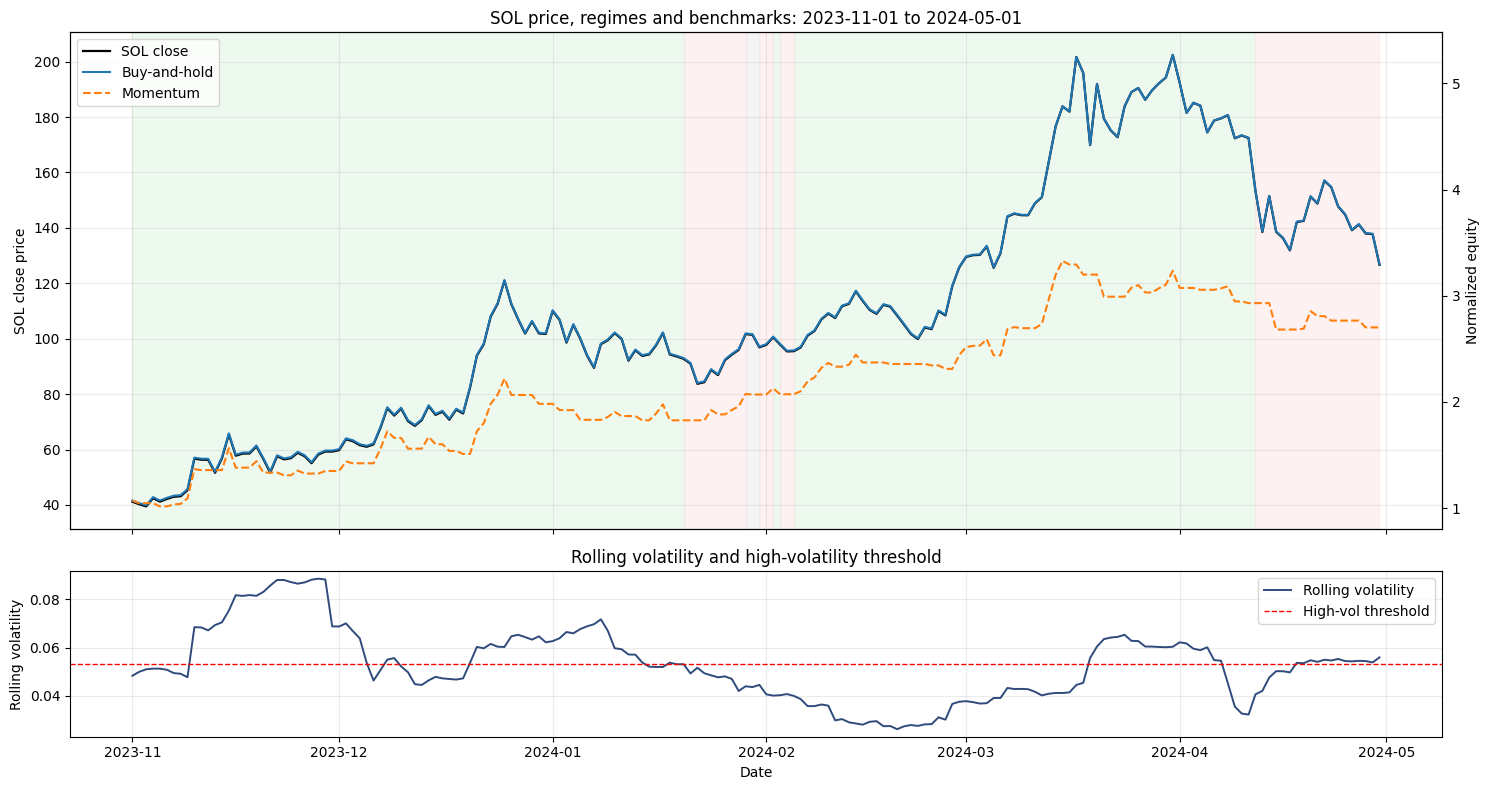

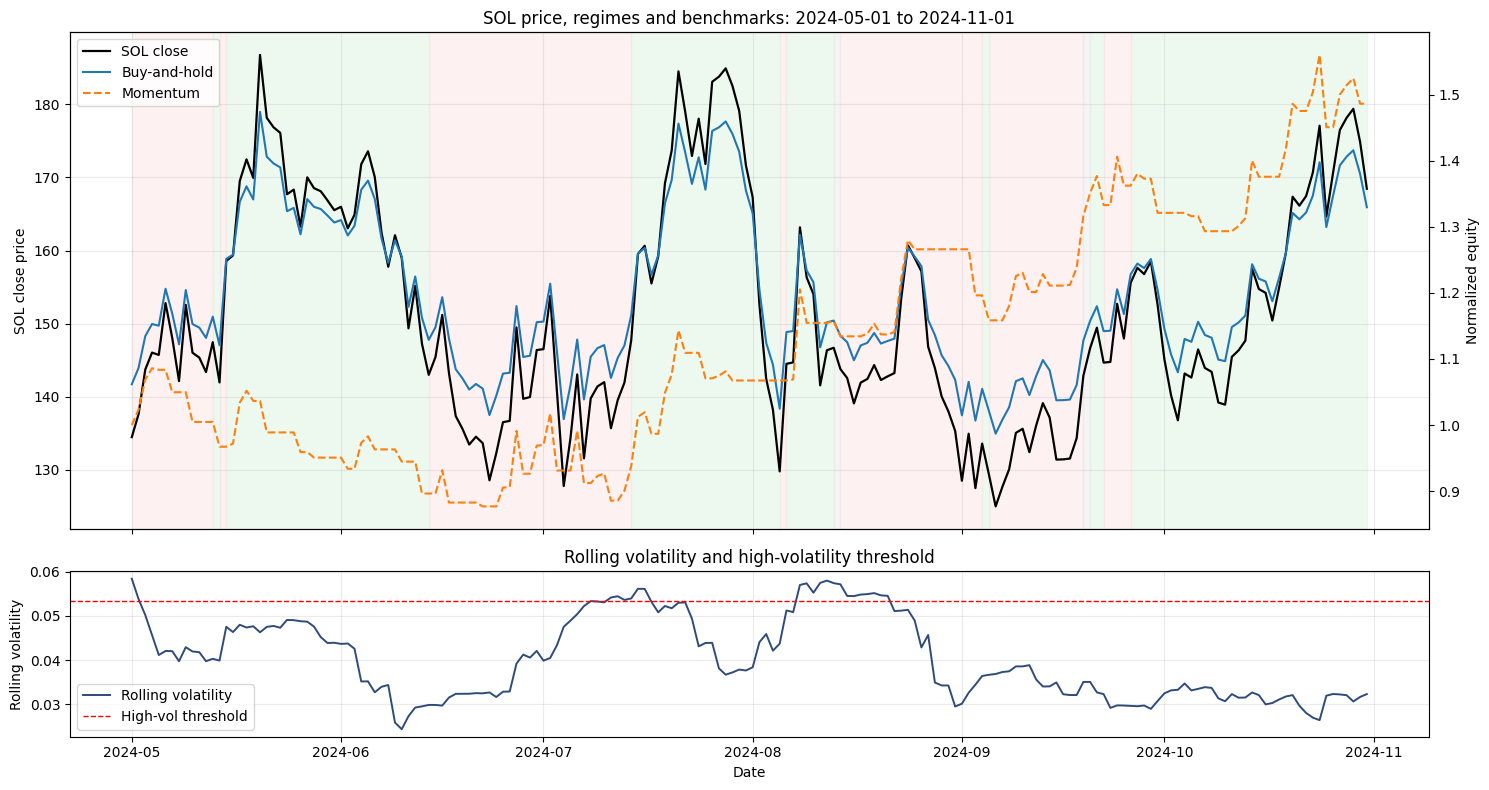

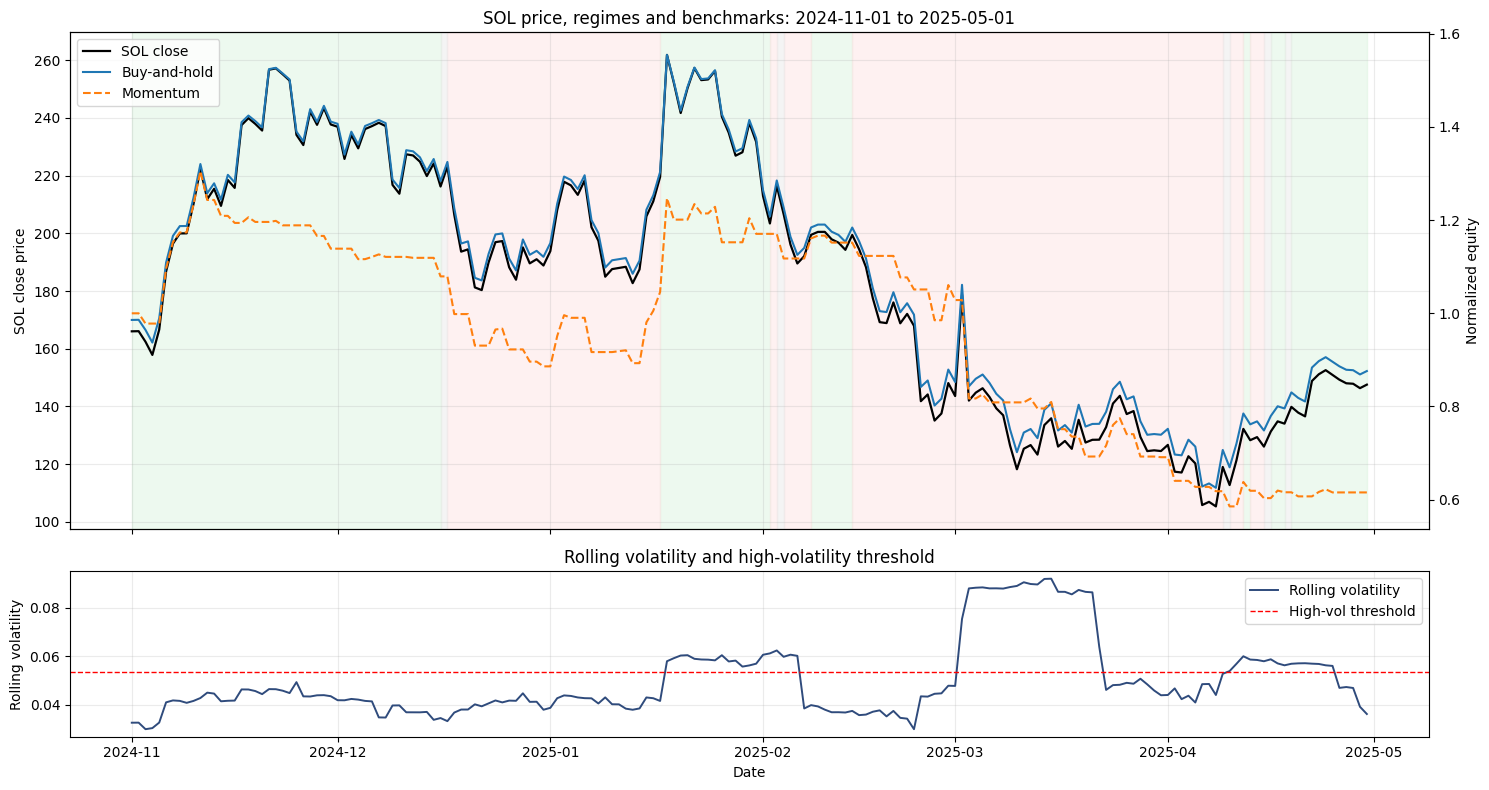

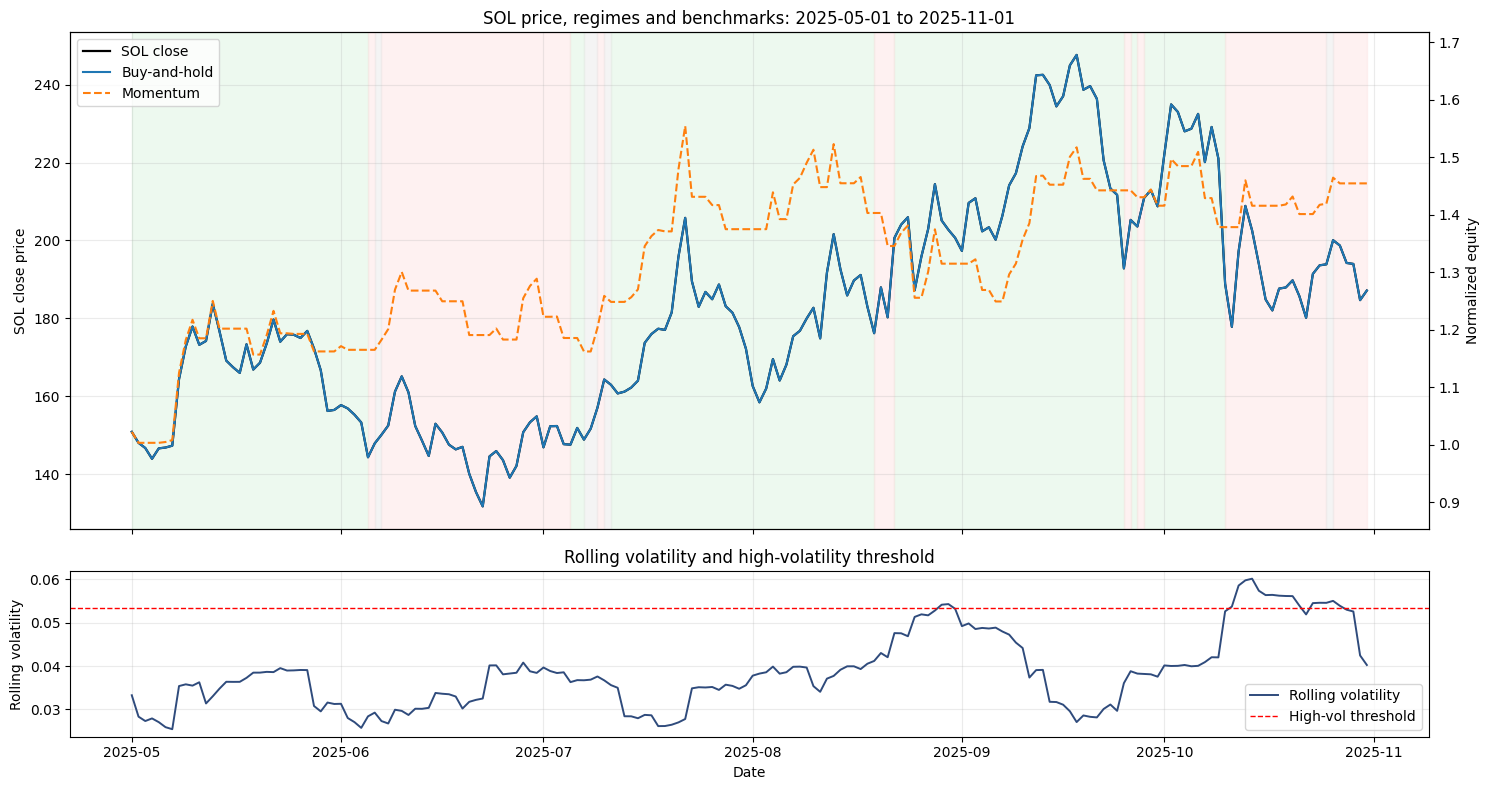

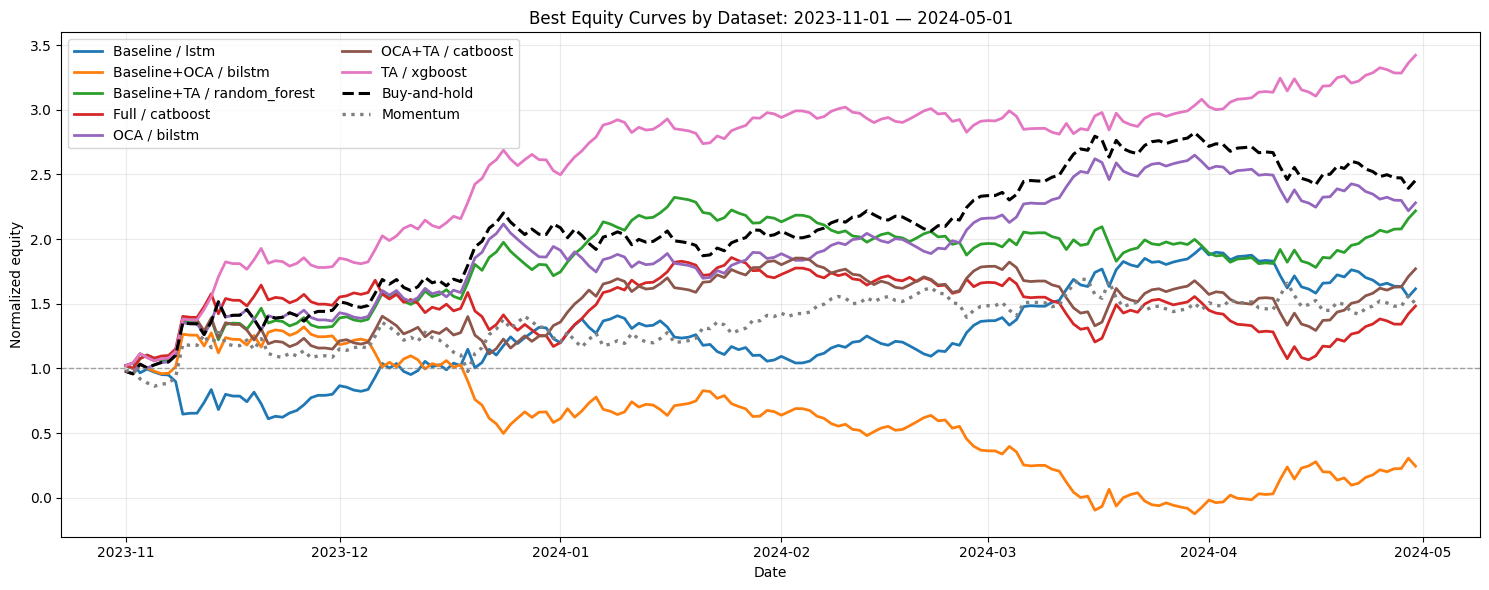

Saved: C:\Users\User\my\py\practise\solana\results\block_ablation_pipeline_full\best_equity_by_dataset_with_benchmarks_20231101_to_20240501.png


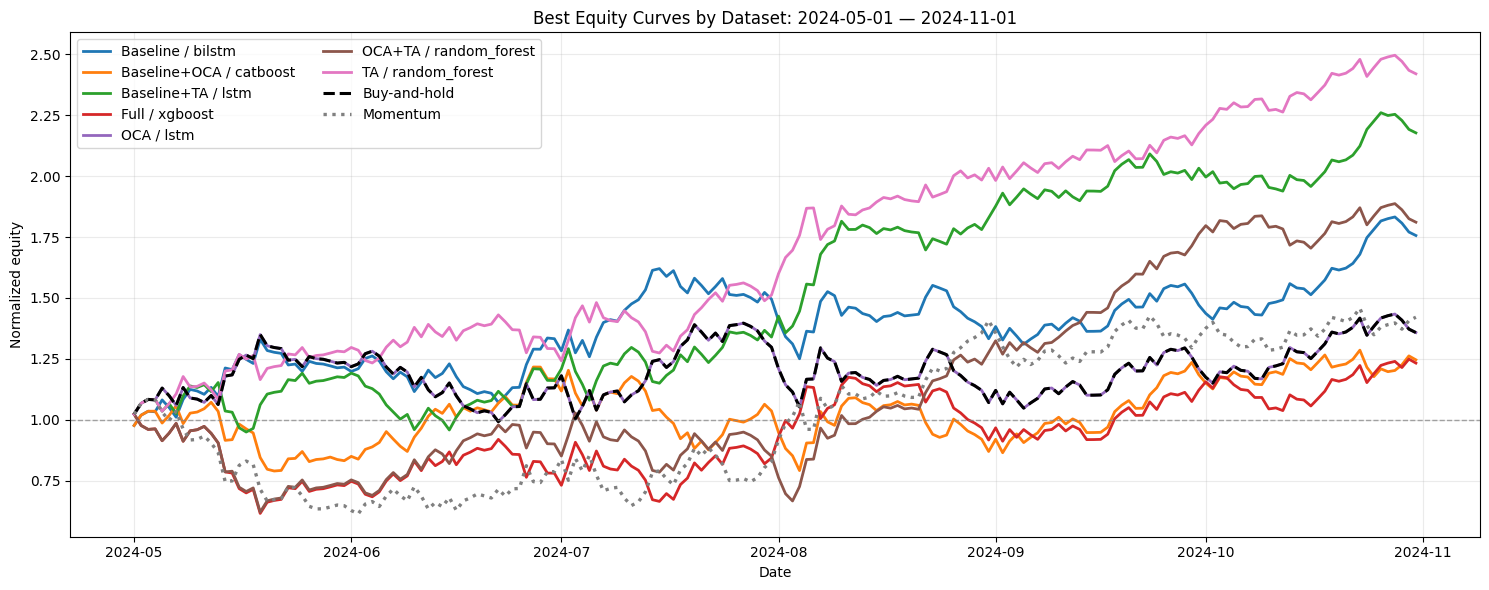

Saved: C:\Users\User\my\py\practise\solana\results\block_ablation_pipeline_full\best_equity_by_dataset_with_benchmarks_20240501_to_20241101.png


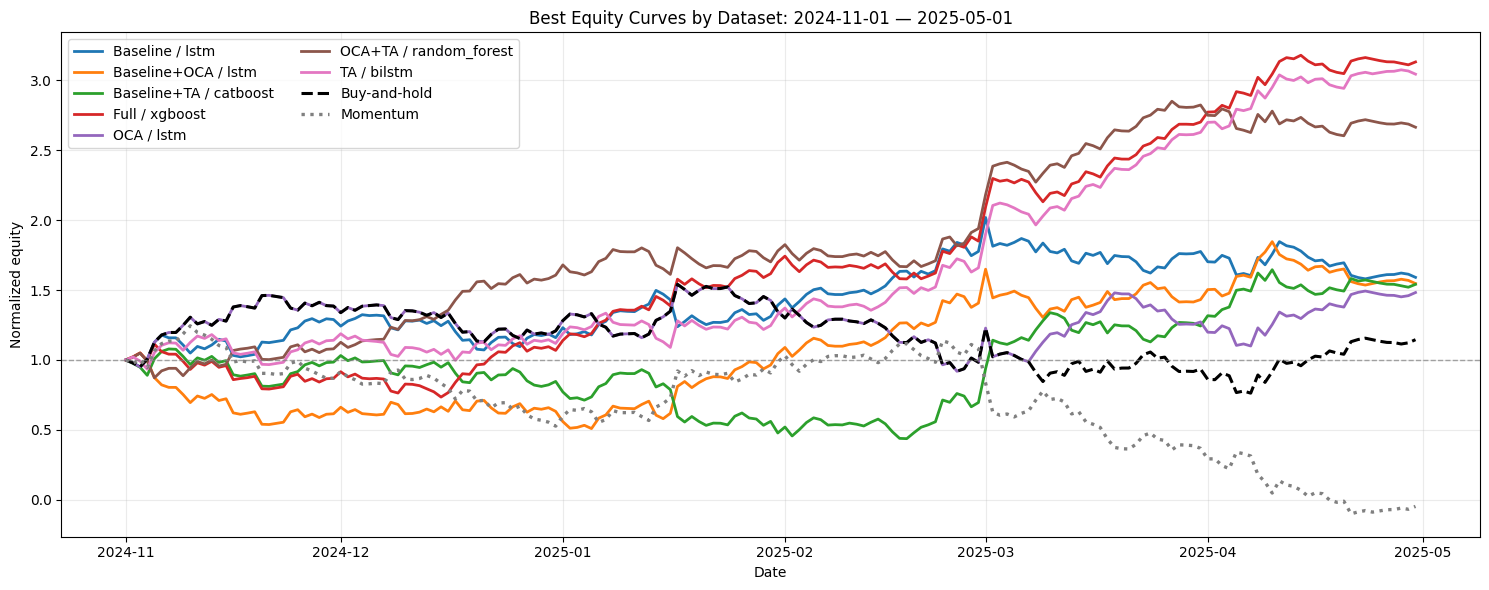

Saved: C:\Users\User\my\py\practise\solana\results\block_ablation_pipeline_full\best_equity_by_dataset_with_benchmarks_20241101_to_20250501.png


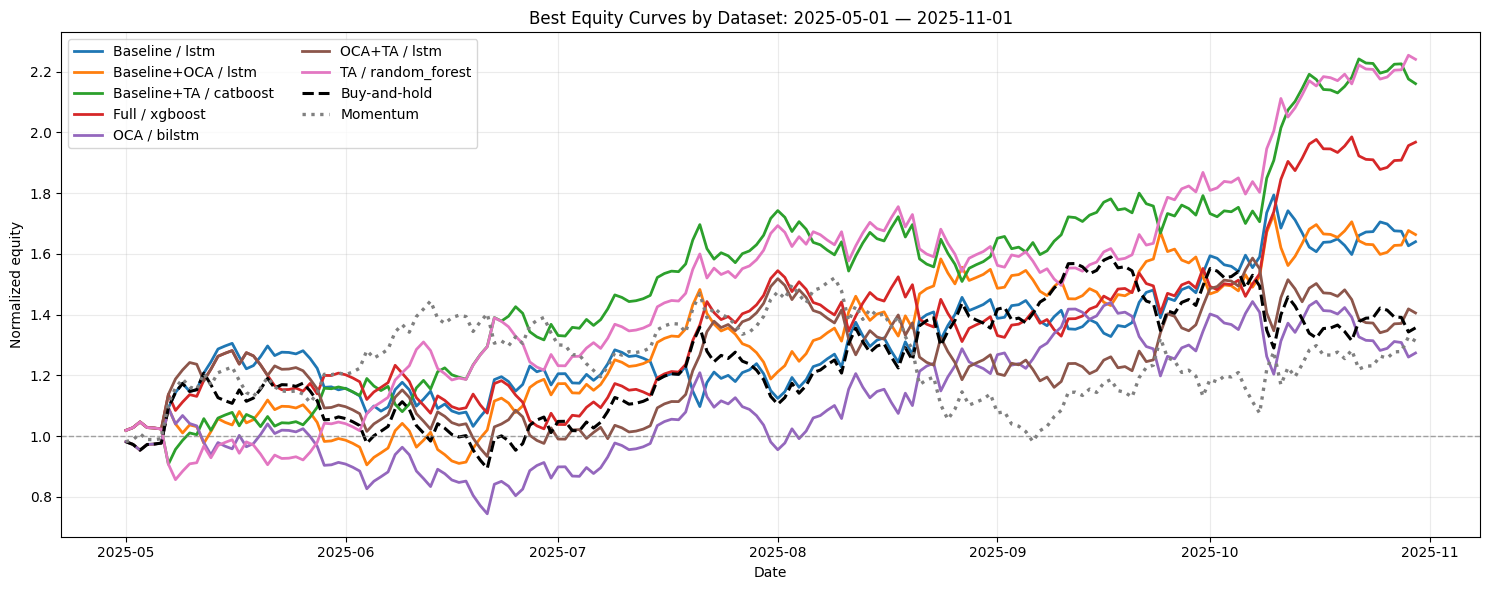

Saved: C:\Users\User\my\py\practise\solana\results\block_ablation_pipeline_full\best_equity_by_dataset_with_benchmarks_20250501_to_20251101.png


In [24]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

results_root = Path(r"C:\Users\User\my\py\practise\solana\results\block_ablation_pipeline_full")

holdout_periods = [
    ("20231101_to_20240501", "2023-11-01", "2024-05-01"),
    ("20240501_to_20241101", "2024-05-01", "2024-11-01"),
    ("20241101_to_20250501", "2024-11-01", "2025-05-01"),
    ("20250501_to_20251101", "2025-05-01", "2025-11-01"),
]

dataset_labels = {
    "baseline": "Baseline",
    "baseline_oca": "Baseline+OCA",
    "baseline_ta": "Baseline+TA",
    "full": "Full",
    "oca": "OCA",
    "oca_ta": "OCA+TA",
    "ta": "TA",
}

benchmark_models = {"always_up", "momentum", "random"}

for holdout_label, start_date, end_date in holdout_periods:
    holdout_dir = results_root / holdout_label

    curves_path = holdout_dir / "equity_curves_same_day_execution.csv"
    stats_path = holdout_dir / "equity_stats.csv"

    curves = pd.read_csv(curves_path)
    stats = pd.read_csv(stats_path)

    curves["date"] = pd.to_datetime(curves["date"])

    # 1. Select best non-benchmark model for each dataset
    model_stats = stats[~stats["model"].isin(benchmark_models)].copy()

    best_by_dataset = (
        model_stats
        .sort_values("total_return", ascending=False)
        .groupby("dataset", as_index=False)
        .first()
    )

    plt.figure(figsize=(15, 6))

    # 2. Plot best equity curve for each dataset
    for _, row in best_by_dataset.iterrows():
        dataset = row["dataset"]
        model = row["model"]

        sub = curves[
            (curves["dataset"] == dataset) &
            (curves["model"] == model)
        ].copy()

        if sub.empty:
            continue

        label = f"{dataset_labels.get(dataset, dataset)} / {model}"

        plt.plot(
            sub["date"],
            sub["equity"],
            linewidth=2,
            label=label
        )

    # 3. Add Buy-and-hold benchmark
    buy_hold = curves[
        (curves["dataset"] == "baseline") &
        (curves["model"] == "always_up")
    ].copy()

    if not buy_hold.empty:
        plt.plot(
            buy_hold["date"],
            buy_hold["equity"],
            color="black",
            linestyle="--",
            linewidth=2.2,
            label="Buy-and-hold"
        )

    # 4. Add Momentum benchmark
    momentum = curves[
        (curves["dataset"] == "baseline") &
        (curves["model"] == "momentum")
    ].copy()

    if not momentum.empty:
        plt.plot(
            momentum["date"],
            momentum["equity"],
            color="gray",
            linestyle=":",
            linewidth=2.4,
            label="Momentum"
        )

    # 5. Reference line at initial equity
    plt.axhline(
        1.0,
        color="gray",
        linestyle="--",
        linewidth=1,
        alpha=0.7
    )

    plt.title(f"Best Equity Curves by Dataset: {start_date} — {end_date}")
    plt.xlabel("Date")
    plt.ylabel("Normalized equity")
    plt.grid(True, alpha=0.25)
    plt.legend(ncol=2)
    plt.tight_layout()

    output_path = results_root / f"best_equity_by_dataset_with_benchmarks_{holdout_label}.png"
    plt.savefig(output_path, dpi=200, bbox_inches="tight")
    plt.show()

    print(f"Saved: {output_path}")


In [29]:
import sys
import importlib.util
from pathlib import Path

PROJECT_DIR = Path(r"C:\Users\User\my\py\practise\solana")
module_path = PROJECT_DIR / "scripts" / "run_article_ready_hypothesis_pipeline.py"

module_name = "article_pipeline_full_run"
spec = importlib.util.spec_from_file_location(module_name, module_path)
article_pipeline = importlib.util.module_from_spec(spec)
sys.modules[module_name] = article_pipeline
spec.loader.exec_module(article_pipeline)

Config = article_pipeline.Config
set_seed = article_pipeline.set_seed
run_block_ablation_from_csvs = article_pipeline.run_block_ablation_from_csvs

cfg = Config(
    fee=0.001,
    feature_selection_mode="fixed_train",
    run_sequence_models=True,
    run_extra_diagnostics=True,
    bootstrap_iters=1000,
    block_bootstrap_iters=1000,
    fee_sensitivity_grid=(0.0, 0.0005, 0.001, 0.002, 0.005),
)

set_seed(cfg.random_state)

holdout_periods = [
    ("2023-11-01", "2024-05-01"),
    ("2024-05-01", "2024-11-01"),
    ("2024-11-01", "2025-05-01"),
    ("2025-05-01", "2025-11-01"),
]

results = run_block_ablation_from_csvs(
    cfg=cfg,
    holdout_periods=holdout_periods,
    out_dir=PROJECT_DIR / "results" / "block_ablation_pipeline_full_v2_stats",
)

print("Done.")
print(results["out_dir"])



=== Ablation holdout: 2023-11-01 to 2024-05-01 ===
Running fixed_train pipeline for baseline...
Running fixed_train pipeline for oca...
Running fixed_train pipeline for ta...
Running fixed_train pipeline for baseline_oca...
Running fixed_train pipeline for baseline_ta...
Running fixed_train pipeline for oca_ta...
Running fixed_train pipeline for full...

Model metrics (fixed_train):
     dataset         model   n  accuracy  balanced_accuracy  precision   recall       f1       mcc  positive_rate  class_1_share  roc_auc    brier  logloss
    baseline     always_up 182  0.532967           0.500000   0.532967 1.000000 0.695341  0.000000       1.000000       0.532967 0.500000 0.249203 0.691557
    baseline          lstm 182  0.538462           0.521164   0.546763 0.783505 0.644068  0.049715       0.763736       0.532967 0.506367 0.249596 0.692340
    baseline      momentum 182  0.527473           0.525409   0.556701 0.556701 0.556701  0.050819       0.532967       0.532967 0.525409 0.24975

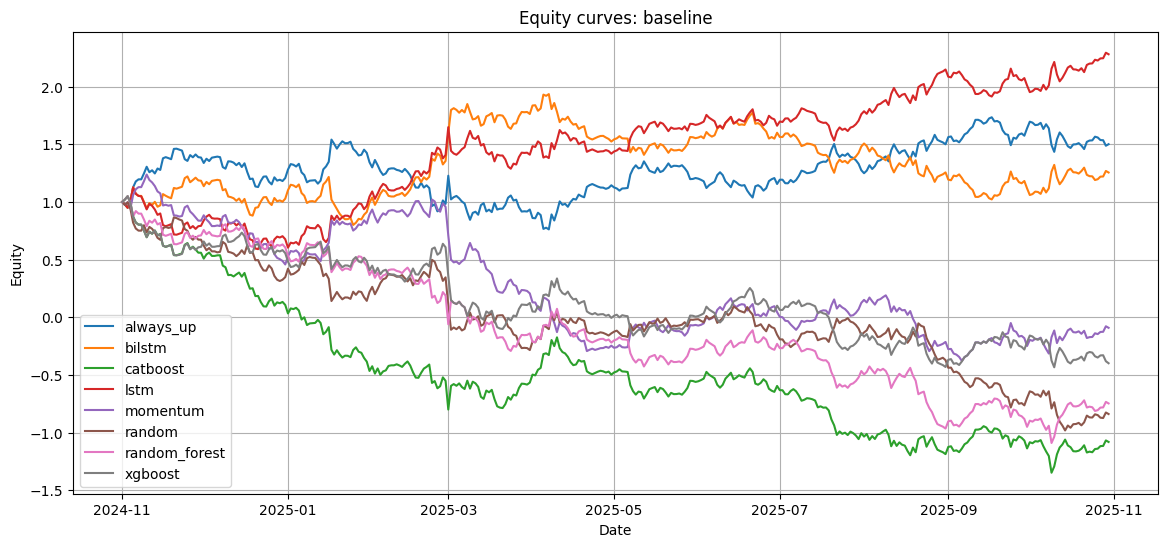

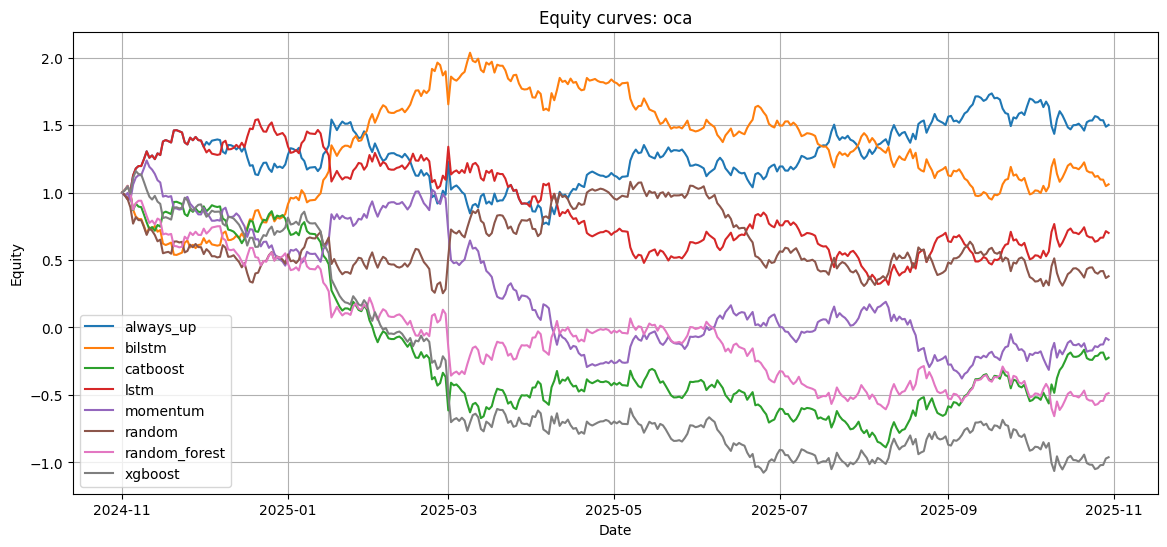

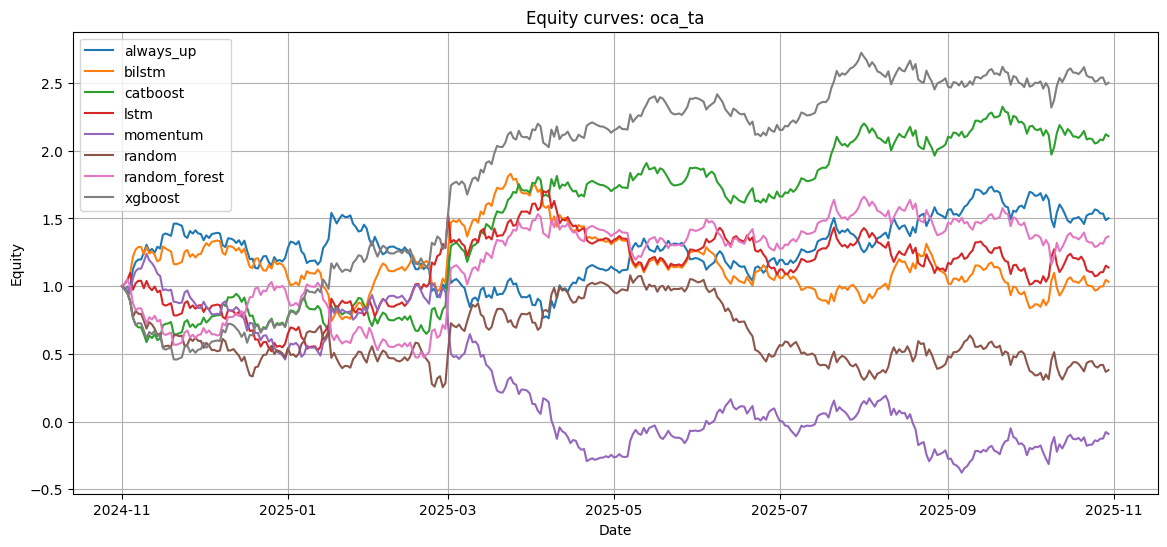

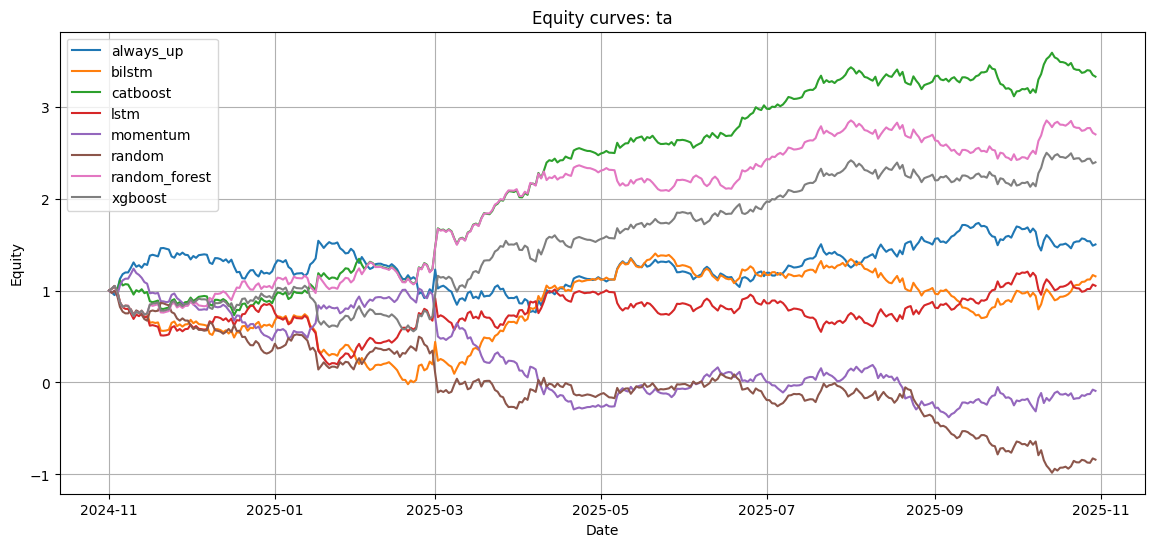

In [44]:
%matplotlib inline

import matplotlib.pyplot as plt
import pandas as pd

eq = artifacts["equity_curves"].copy()
eq["date"] = pd.to_datetime(eq["date"])
eq["equity"] = pd.to_numeric(eq["equity"], errors="coerce")

eq = (
    eq
    .dropna(subset=["date", "equity"])
    .drop_duplicates(subset=["dataset", "model", "date"], keep="last")
    .sort_values(["dataset", "model", "date"])
)

for dataset, tmp in eq.groupby("dataset"):
    plt.figure(figsize=(14, 6))
    
    for model, m in tmp.groupby("model"):
        plt.plot(m["date"], m["equity"], label=model)
    
    plt.title(f"Equity curves: {dataset}")
    plt.xlabel("Date")
    plt.ylabel("Equity")
    plt.grid(True)
    plt.legend()
    plt.show()



In [116]:
results_df=artifacts["comparison_table"]
results_df = results_df[results_df['model'] != 'always_up']
results_df = results_df[results_df['model'] != 'random']
baseline_models = ['random', 'momentum', 'always_up', 'buy_and_hold']

main_df = results_df[~results_df['model'].isin(baseline_models)]

baseline_df = (
    results_df[results_df['model'].isin(baseline_models)]
    .drop_duplicates(subset=['model'])
)

final_df = pd.concat([main_df, baseline_df], ignore_index=True)

final_df

,dataset,model,threshold,accuracy,precision,recall,f1,roc_auc,logloss,total_return,sharpe,max_drawdown,win_rate,n_periods
0,oca,catboost,0.5,0.497253,0.505208,0.524324,0.514589,0.489446,0.737786,-0.261476,-0.298835,-1.671145,0.489011,364
1,oca,xgboost,0.5,0.461538,0.469274,0.454054,0.461538,0.481745,0.777498,-0.671003,-0.766238,-1.696149,0.450549,364
2,oca,logreg,0.5,0.494505,0.502732,0.497297,0.500000,0.496633,0.717912,-0.381756,-0.435992,-0.621558,0.491758,364
3,oca,random_forest,0.5,0.472527,0.478528,0.421622,0.448276,0.479179,0.705762,-0.921634,-1.053265,-1.891578,0.464286,364
4,oca,knn,0.5,0.439560,0.450777,0.470270,0.460317,0.452152,0.748560,-1.391948,-1.593712,-2.222029,0.436813,364
5,oca,lstm,0.5,0.530220,0.542169,0.486486,0.512821,0.544496,0.857610,0.300724,0.343471,-0.635874,0.527473,364
6,oca,bilstm,0.5,0.502747,0.510309,0.535135,0.522427,0.508078,1.007302,0.978731,1.119355,-0.742516,0.500000,364
7,ta,catboost,0.5,0.513736,0.545455,0.259459,0.351648,0.576627,0.745620,2.124440,2.451089,-0.486082,0.510989,364
8,ta,xgboost,0.5,0.505495,0.524752,0.286486,0.370629,0.562283,0.814164,1.476218,1.694578,-0.518252,0.505495,364
9,ta,logreg,0.5,0.535714,0.550633,0.470270,0.507289,0.573396,0.696606,2.714611,3.151730,-0.552590,0.535714,364


In [117]:
artifacts["feature_stability_summary"].query("dataset == 'oca' and model == 'catboost'")

,dataset,model,feature,mean_feature_importance,std_feature_importance,mean_shap,std_shap,mean_permutation,std_permutation,n_folds,n_positive,n_negative,n_available,abs_mean_permutation,cv_permutation,positive_share,sign_consistency,mean_rank,std_rank,stability_score
0,oca,catboost,spike_netflow,8.481737,1.222793,0.166456,0.162019,-0.023425,0.005675,5,0,5,5,0.023425,0.242241,0.0,1.0,14.2,1.788854,0.023293
1,oca,catboost,spike_inflow,6.186471,0.579162,0.104596,0.067407,0.017281,0.027262,5,4,1,5,0.017281,1.577564,0.8,0.8,3.6,3.974921,0.013458
2,oca,catboost,median_amount,7.184410,0.797254,0.167447,0.111998,-0.012186,0.011114,5,1,4,5,0.012186,0.912041,0.2,0.8,11.0,2.000000,0.009641
3,oca,catboost,rolling_netflow_3h_normed,7.650907,0.550967,0.111539,0.041834,-0.011118,0.012486,5,1,4,5,0.011118,1.123039,0.2,0.8,11.8,2.588436,0.008784
4,oca,catboost,rolling_outflow_mean_spike,5.821867,0.671108,0.149030,0.119938,0.007487,0.011034,5,3,2,5,0.007487,1.473706,0.6,0.6,5.6,4.615192,0.004443
5,oca,catboost,spike_outflow,5.638430,0.516904,0.099784,0.015391,0.007501,0.021763,5,3,2,5,0.007501,2.901248,0.6,0.6,5.4,5.128353,0.004405
6,oca,catboost,rolling_netflow_3h,5.938518,0.739702,0.105296,0.044822,-0.007238,0.013479,5,2,3,5,0.007238,1.862204,0.4,0.6,10.2,3.563706,0.004285
7,oca,catboost,spike_tx,7.792999,0.508647,0.103071,0.043883,0.006206,0.011870,5,3,2,5,0.006206,1.912573,0.6,0.6,5.6,2.302173,0.003680
8,oca,catboost,rolling_whale_share_mean_spike,6.496022,0.771714,0.103657,0.021328,-0.005617,0.014921,5,2,3,5,0.005617,2.656206,0.4,0.6,8.0,4.636809,0.003321
9,oca,catboost,total_volume,5.457523,0.690692,0.101865,0.063091,-0.004215,0.015920,5,1,4,5,0.004215,3.776534,0.2,0.8,9.2,3.701351,0.003320


In [115]:
oca_cat_stability = artifacts["feature_stability_summary"].query(
    "dataset == 'oca' and model == 'catboost'"
).sort_values("stability_score", ascending=False)

oca_cat_stability[[
    "feature", "mean_permutation", "std_permutation",
    "sign_consistency", "mean_rank", "stability_score"
]].head(15)

,feature,mean_permutation,std_permutation,sign_consistency,mean_rank,stability_score
0,spike_netflow,-0.023425,0.005675,1.0,14.2,0.023293
1,spike_inflow,0.017281,0.027262,0.8,3.6,0.013458
2,median_amount,-0.012186,0.011114,0.8,11.0,0.009641
3,rolling_netflow_3h_normed,-0.011118,0.012486,0.8,11.8,0.008784
4,rolling_outflow_mean_spike,0.007487,0.011034,0.6,5.6,0.004443
5,spike_outflow,0.007501,0.021763,0.6,5.4,0.004405
6,rolling_netflow_3h,-0.007238,0.013479,0.6,10.2,0.004285
7,spike_tx,0.006206,0.011870,0.6,5.6,0.003680
8,rolling_whale_share_mean_spike,-0.005617,0.014921,0.6,8.0,0.003321
9,total_volume,-0.004215,0.015920,0.8,9.2,0.003320


In [97]:
artifacts["regime_results"]

{'oca': {'catboost': {'metrics_by_regime':    accuracy  precision    recall        f1   roc_auc   logloss  \
   0  0.590909   0.619048  0.565217  0.590909  0.612836  0.661156   
   1  0.571429   0.568966  0.622642  0.594595  0.541001  0.710006   
   2  0.370370   0.230769  0.300000  0.260870  0.364706  0.792704   
   3  0.449438   0.468085  0.478261  0.473118  0.436805  0.765082   
   
       market_regime  n_obs  
   0  bear__high_vol     44  
   1   bear__low_vol    105  
   2  bull__high_vol     27  
   3   bull__low_vol    178  ,
   'transition_degradation': {'accuracy_transition': 0.5454545454545454,
    'precision_transition': 0.6071428571428571,
    'recall_transition': 0.6538461538461539,
    'f1_transition': 0.6296296296296297,
    'roc_auc_transition': np.float64(0.5790598290598291),
    'logloss_transition': 0.6733218574094187,
    'accuracy_stable': 0.490625,
    'precision_stable': 0.4878048780487805,
    'recall_stable': 0.5031446540880503,
    'f1_stable': 0.495356037151